In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")



Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL\hbmnl_mixture_experiments\2_chains\3_comp
scenario=3comp_equal  K_MODEL=5  K_TRUE=3
samplers found: ['bayesm', 'HMC', 'NUTS']
  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids (FULL, UNBOUNDED) ──────────
# ALTERNATIVE grid: NO clipping bounds. Spans the full support of every component
# (all K, incl. surplus/empty ones) of every sampler AND the True DGP, via the raw
# min/max envelope - no live-only selection, no percentile trim. Every metric below
# is therefore computed over the ENTIRE true marginal: no part is excluded.
# Contrast marginal_comparison.ipynb, which clips to the fitted live-component region.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

grids = mc.build_grids_full(models, true_model, n_grid=4000, n_sigma=6)
print("Grid extents (FULL support, all components + True DGP, untrimmed):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (FULL support, all components + True DGP, untrimmed):
  Alt1       [-1298.31, +1597.90]
  Alt2       [-721.12, +629.68]
  Alt3       [-474.50, +467.38]
  Price      [-303.65, +456.23]


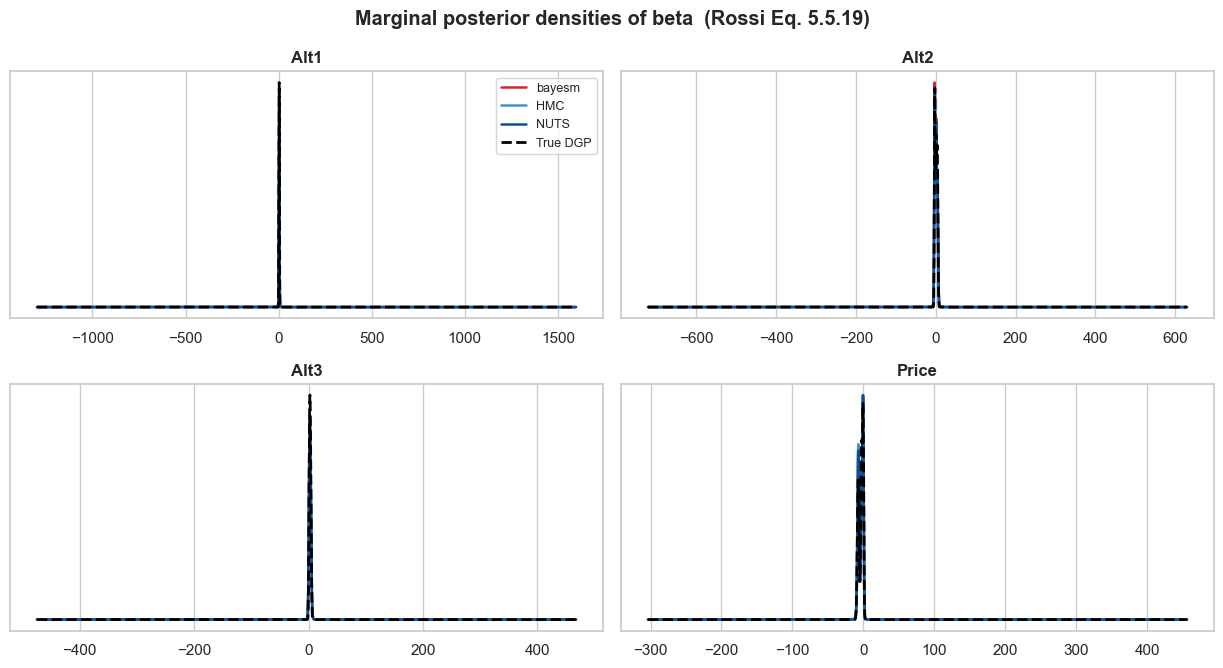

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Marginal posterior densities of beta  (Rossi Eq. 5.5.19)", fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them.
display(mc.distance_table(models, true_model, grids, param_names))

c:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL\src\marginal_comparison.py:191: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger   KL      JSD      TVD  Wasserstein1
sampler param                                                
bayesm  Alt1     0.07251  inf  0.00481  0.05077       0.16629
        Alt2     0.07396  inf  0.00512  0.06383       0.23964
        Alt3     0.07912  inf  0.00593  0.07192       0.19914
        Price    0.05604  inf  0.00291  0.05656       0.17852
HMC     Alt1     0.10312  inf  0.00929  0.07030       0.36676
        Alt2     0.09800  inf  0.00851  0.06622       0.44797
        Alt3     0.09777  inf  0.00873  0.08362       0.28173
        Price    0.07900  inf  0.00561  0.07294       0.27912
NUTS    Alt1     0.10467  inf  0.00968  0.07771       0.33776
        Alt2     0.09333  inf  0.00788  0.06978       0.36794
        Alt3     0.09393  inf  0.00790  0.07519       0.26099
        Price    0.06086  inf  0.00338  0.06000       0.24794

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,True DGP
Alt1,2.824,3.006,2.950,2.719
Alt2,0.623,0.422,0.550,0.781
Alt3,2.517,2.455,2.491,2.635
Price,-3.606,-3.705,-3.672,-3.454


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,True DGP
Alt1,2.665,9.659,6.436,2.072
Alt2,9.795,10.759,11.198,8.600
Alt3,2.725,4.326,4.302,1.993
Price,9.697,10.618,10.848,9.352


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,2,1377.885,2160.893,1.001,1.001
Alt2,1,934.631,934.631,1.000,1.000
Alt3,2,935.364,1120.107,1.003,1.002
Price,2,138.256,606.165,1.010,1.007


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,3,4.384,45.804,1.390,1.230
Alt2,1,11.576,11.576,1.131,1.131
Alt3,3,14.945,26.497,1.109,1.076
Price,2,14.909,104.667,1.106,1.057


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,2,99.042,767.732,1.014,1.009
Alt2,1,141.259,141.259,1.026,1.026
Alt3,3,256.728,345.579,1.011,1.005
Price,2,654.201,1058.936,1.002,1.001


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - The grid is anchored to the fitted models' live-component support; the True")
print("   DGP is an overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- bayesm ---


ESS    Rhat
param moment                   
Alt1  Mean     760.9175  1.0038
      Var      983.5324  1.0046
Alt2  Mean    1245.0198  1.0007
      Var      700.8123  1.0017
Alt3  Mean    1199.1225  1.0007
      Var     1114.3913  1.0006
Price Mean     667.8325  1.0054
      Var      160.2739  1.0175

--- HMC ---


ESS    Rhat
param moment                 
Alt1  Mean     7.9165  1.1814
      Var      4.0026  1.4416
Alt2  Mean     4.6576  1.3593
      Var      9.7299  1.1614
Alt3  Mean    30.4075  1.0780
      Var      6.9076  1.2191
Price Mean    28.7847  1.0710
      Var     25.8821  1.0886

--- NUTS ---


ESS    Rhat
param moment                  
Alt1  Mean    143.0599  1.0099
      Var     102.4774  1.0275
Alt2  Mean      7.6561  1.1819
      Var      85.6248  1.0348
Alt3  Mean    309.7141  1.0090
      Var     110.9342  1.0201
Price Mean    315.9547  1.0204
      Var     196.6258  1.0329


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - The grid is anchored to the fitted models' live-component support; the True
   DGP is an overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
